# Spatio-Temporal Crime Pattern Analysis in the UK Using Police Open Data


## 1. Project Introduction

Crime data analysis is the process of systematically examining recorded crime events to identify patterns, trends, concentrations, anomalies, and potential explanatory structures across time and space. In data science and criminology, exploratory analysis is a foundational step that helps transform raw event-level records into interpretable evidence for policy, urban safety planning, hotspot identification, and subsequent predictive or clustering models.

The analysis of UK crime patterns is important because it supports evidence-based policing, reveals temporal peaks and seasonality, identifies spatial hotspots, enables regional comparison, and prepares the data for later modelling.

### EDA objective
The objective of this notebook is to produce an extensive, academically structured exploratory analysis of the UK Police open crime dataset, with emphasis on:
- dataset structure and quality,
- missing data and cleaning requirements,
- offence-type distributions,
- long-term and short-term temporal patterns,
- spatial distributions and geographic concentration,
- cross-tabulated spatio-temporal summaries, and
- preparation of aggregated features for later clustering or hotspot analysis.


## 2. Dataset Description

### Dataset source
The dataset used in this study comes from the **UK Police Open Data portal**: `https://data.police.uk/data/`.

### Typical variables in UK Police street crime files
The exact variables available may vary slightly by file or release, but typical columns include:
- `Crime ID`
- `Month`
- `Reported by`
- `Falls within`
- `Longitude`
- `Latitude`
- `Location`
- `LSOA code`
- `LSOA name`
- `Crime type`
- `Last outcome category`
- `Context`

### Expected analytical coverage
This notebook is designed to work with the **full manually downloaded dataset**, potentially containing:
- multiple police forces,
- multiple months or years,
- millions of records,
- repeated spatial coordinates, and
- multiple crime categories.

### Note on dataset size
For full UK-wide analysis, the dataset may be too large for naive loading in memory. Therefore, this notebook uses a robust workflow: recursive file discovery, controlled full combine, aggregation-focused EDA for large data, and export of combined and cleaned files to Drive.


## 3. Environment Setup


In [1]:
# Install required Python libraries quietly (-q suppresses output)
# pyarrow      → for efficient columnar data processing (used with pandas/Parquet)
# geopandas    → for working with geospatial (GIS) data in Python
# contextily   → for adding base maps (tiles) to geospatial plots
# plotly       → for interactive visualizations and dashboards

!pip -q install pyarrow geopandas contextily plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.5/342.5 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 138.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.1/94.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 3.6 MB/s eta 0:00:00


In [2]:
# ineraction with files and directories
import os

# helps free up unused memory automatically
import gc

# for pattern matching in file paths (e.g., *.csv)
import glob

# to control warning messages in Python
import warnings

# easier way to handle filesystem paths
from pathlib import Path


# for numerical computing and array operations
import numpy as np

# for data manipulation and analysis (DataFrames, CSV handling, etc.)
import pandas as pd

# for data visualization and plotting
import matplotlib.pyplot as plt

# statistical data visualization built on top of matplotlib
import seaborn as sns

# interactive and dynamic visualizations
import plotly.express as px


# ignores all warning messages to keep output clean
warnings.filterwarnings('ignore')

# shows up to 100 columns when displaying pandas DataFrames
pd.set_option('display.max_columns', 100)

# shows up to 200 rows when displaying pandas DataFrames
pd.set_option('display.max_rows', 200)

# points numbers to 4 decimal places for better readability
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# for consistent and clean plots
sns.set_theme(style='whitegrid')

## 4. Google Drive Mounting and Dataset Loading

This notebook assumes that you downloaded the official UK Police dataset manually and uploaded all CSV files to a folder in **Google Drive**.


In [3]:

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Path to the main dataset folder in Google Drive containing UK Police data
DATA_ROOT = '/content/drive/MyDrive/UK_Police_Full_Dataset'

# If True, search for files in all subfolders (recursively) inside DATA_ROOT
RECURSIVE_SEARCH = True

# If True, only include files related to street crime data (filtering dataset scope)
ONLY_STREET_CRIME_FILES = True

# If True, exclude already combined/merged output files from processing
EXCLUDE_COMBINED_OUTPUTS = True

# Number of rows to read at a time when processing large datasets (memory optimization)
CHUNK_SIZE = 200_000

# Directory where all analysis outputs (plots, processed files, results) will be saved
OUTPUT_DIR = '/content/drive/MyDrive/UK_Police_EDA_Outputs'

# Create OUTPUT_DIR if it doesn't already exist (avoid errors when saving files later)
os.makedirs(OUTPUT_DIR, exist_ok=True)


# Print dataset root path for verification
print('DATA_ROOT:', DATA_ROOT)

# Print output directory path for verification
print('OUTPUT_DIR:', OUTPUT_DIR)

DATA_ROOT: /content/drive/MyDrive/UK_Police_Full_Dataset
OUTPUT_DIR: /content/drive/MyDrive/UK_Police_EDA_Outputs


In [5]:
# Define search pattern for CSV files
# If recursive search is enabled, look in all subfolders (**/*.csv)
# Otherwise, only look in the main directory (*.csv)
search_pattern = '**/*.csv' if RECURSIVE_SEARCH else '*.csv'

# Find all CSV files matching the pattern inside DATA_ROOT
# recursive=True ensures subdirectory search when needed
all_csv_files = glob.glob(os.path.join(DATA_ROOT, search_pattern), recursive=RECURSIVE_SEARCH)


# If enabled, remove files that are likely outputs of previous processing steps
# This avoids re-processing already combined/cleaned/summary datasets
if EXCLUDE_COMBINED_OUTPUTS:
    all_csv_files = [
        f for f in all_csv_files
        if 'combined' not in os.path.basename(f).lower()
        and 'cleaned' not in os.path.basename(f).lower()
        and 'summary' not in os.path.basename(f).lower()
    ]


# If enabled, keep only files related to street crime datasets
# Filtering is based on filename containing the word 'street'
if ONLY_STREET_CRIME_FILES:
    all_csv_files = [
        f for f in all_csv_files
        if 'street' in os.path.basename(f).lower()
    ]


# Sort file list for consistent ordering (important for reproducibility)
all_csv_files = sorted(all_csv_files)

# Print total number of CSV files found after filtering
print(f'Number of CSV files discovered: {len(all_csv_files)}')

# Display first 10 file paths to verify selection
all_csv_files[:10]

Number of CSV files discovered: 1566


['/content/drive/MyDrive/UK_Police_Full_Dataset/2023-02/2023-02-avon-and-somerset-street.csv',
 '/content/drive/MyDrive/UK_Police_Full_Dataset/2023-02/2023-02-bedfordshire-street.csv',
 '/content/drive/MyDrive/UK_Police_Full_Dataset/2023-02/2023-02-btp-street.csv',
 '/content/drive/MyDrive/UK_Police_Full_Dataset/2023-02/2023-02-cambridgeshire-street.csv',
 '/content/drive/MyDrive/UK_Police_Full_Dataset/2023-02/2023-02-cheshire-street.csv',
 '/content/drive/MyDrive/UK_Police_Full_Dataset/2023-02/2023-02-city-of-london-street.csv',
 '/content/drive/MyDrive/UK_Police_Full_Dataset/2023-02/2023-02-cleveland-street.csv',
 '/content/drive/MyDrive/UK_Police_Full_Dataset/2023-02/2023-02-cumbria-street.csv',
 '/content/drive/MyDrive/UK_Police_Full_Dataset/2023-02/2023-02-derbyshire-street.csv',
 '/content/drive/MyDrive/UK_Police_Full_Dataset/2023-02/2023-02-devon-and-cornwall-street.csv']

In [6]:
# Check if no CSV files were found after applying all filters
# This is a safety check to ensure dataset paths and filters are correct
if len(all_csv_files) == 0:
    # Raise an error if dataset is missing or incorrectly filtered
    # This helps catch issues early (wrong path, empty folder, or overly strict filters)
    raise FileNotFoundError(
        'No CSV files were found. Check DATA_ROOT, extraction status, and filter settings.'
    )

### 4.1 File Inventory


In [7]:
# Create a DataFrame to store metadata (inventory) of all discovered CSV files
file_inventory = pd.DataFrame({'file_path': all_csv_files})

# Extract just the file name from full file path (e.g., data.csv)
file_inventory['file_name'] = file_inventory['file_path'].apply(os.path.basename)

# Extract parent folder name for each file (useful for grouping by region/category/year)
file_inventory['parent_folder'] = file_inventory['file_path'].apply(lambda x: Path(x).parent.name)

# Calculate file size in megabytes (MB) for each CSV file
file_inventory['file_size_mb'] = file_inventory['file_path'].apply(
    lambda x: os.path.getsize(x) / (1024**2)
)

# Display first few rows of the file inventory for inspection
display(file_inventory.head())

# Print total dataset size in gigabytes (GB)
print('Total file size (GB):', round(file_inventory['file_size_mb'].sum() / 1024, 3))

# Print median file size in megabytes (MB) to understand typical file size
print('Median file size (MB):', round(file_inventory['file_size_mb'].median(), 3))

,file_path,file_name,parent_folder,file_size_mb
0,/content/drive/MyDrive/UK_Police_Full_Dataset/...,2023-02-avon-and-somerset-street.csv,2023-02,2.9822
1,/content/drive/MyDrive/UK_Police_Full_Dataset/...,2023-02-bedfordshire-street.csv,2023-02,0.9571
2,/content/drive/MyDrive/UK_Police_Full_Dataset/...,2023-02-btp-street.csv,2023-02,0.4562
3,/content/drive/MyDrive/UK_Police_Full_Dataset/...,2023-02-cambridgeshire-street.csv,2023-02,1.5591
4,/content/drive/MyDrive/UK_Police_Full_Dataset/...,2023-02-cheshire-street.csv,2023-02,1.7703


Total file size (GB): 3.821
Median file size (MB): 1.78


## 5. Schema Inspection and Harmonisation Strategy


In [8]:
# List to store schema information (columns + structure) from sampled CSV files
schema_records = []

# Take a sample of up to 50 files to analyze structure (avoid heavy computation)
sample_for_schema = all_csv_files[:min(len(all_csv_files), 50)]


# Loop through sampled files to inspect their column structure
for fp in sample_for_schema:
    try:
        # Read only first 5 rows to quickly infer schema without loading full file
        tmp = pd.read_csv(fp, nrows=5)

        # Store schema details for successful reads
        schema_records.append({
            'file_name': os.path.basename(fp),
            'n_columns': len(tmp.columns),
            'columns': list(tmp.columns)
        })

    except Exception as e:
        # If file cannot be read, store error information instead of crashing
        schema_records.append({
            'file_name': os.path.basename(fp),
            'n_columns': np.nan,
            'columns': [f'READ_ERROR: {e}']
        })


# Convert collected schema information into a DataFrame for analysis
schema_df = pd.DataFrame(schema_records)

# Display schema summary for first few files
display(schema_df.head())


# Build a unified (harmonised) list of all unique columns across sampled datasets
# This helps understand common structure across multiple CSV files
harmonised_columns = sorted({
    col
    for cols in schema_df['columns']
    if isinstance(cols, list) and not any(str(c).startswith('READ_ERROR') for c in cols)
    for col in cols
})


# Print the final harmonised column list
print('Harmonised columns identified from sampled files:')
print(harmonised_columns)

,file_name,n_columns,columns
0,2023-02-avon-and-somerset-street.csv,12,"[Crime ID, Month, Reported by, Falls within, L..."
1,2023-02-bedfordshire-street.csv,12,"[Crime ID, Month, Reported by, Falls within, L..."
2,2023-02-btp-street.csv,12,"[Crime ID, Month, Reported by, Falls within, L..."
3,2023-02-cambridgeshire-street.csv,12,"[Crime ID, Month, Reported by, Falls within, L..."
4,2023-02-cheshire-street.csv,12,"[Crime ID, Month, Reported by, Falls within, L..."


Harmonised columns identified from sampled files:
['Context', 'Crime ID', 'Crime type', 'Falls within', 'LSOA code', 'LSOA name', 'Last outcome category', 'Latitude', 'Location', 'Longitude', 'Month', 'Reported by']


In [9]:
# Define the standard set of important columns expected in UK Police crime datasets
# These are commonly used fields for analysis (time, location, crime type, etc.)
EXPECTED_PRIORITY_COLUMNS = [
    'Crime ID',              # Unique identifier for each crime record
    'Month',                # Reporting month of the crime
    'Reported by',          # Police force that reported the crime
    'Falls within',         # Police force area where crime falls under jurisdiction
    'Longitude',           # Geographic longitude coordinate
    'Latitude',            # Geographic latitude coordinate
    'Location',            # Text description of location
    'LSOA code',           # Lower Super Output Area code (small geographic area)
    'LSOA name',           # Human-readable LSOA name
    'Crime type',          # Category/type of crime
    'Last outcome category', # Final recorded outcome of the crime
    'Context',             # Additional contextual information (if available)
]

# Filter expected columns to only those that actually exist in the discovered datasets
# This ensures compatibility across files with different schemas
available_priority_columns = [
    c for c in EXPECTED_PRIORITY_COLUMNS
    if c in harmonised_columns
]

# Display final list of usable priority columns
available_priority_columns

['Crime ID',
 'Month',
 'Reported by',
 'Falls within',
 'Longitude',
 'Latitude',
 'Location',
 'LSOA code',
 'LSOA name',
 'Crime type',
 'Last outcome category',
 'Context']

## 6. Robust Multi-File Loading and Combination


In [10]:
# Function to read a CSV file and standardise its structure across different datasets
def read_and_standardise_csv(file_path, harmonised_cols=None):

    # Read CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)

    # Add metadata column to track the origin file name
    df['source_file'] = os.path.basename(file_path)

    # Add metadata column to track the parent folder (useful for grouping datasets)
    df['source_folder'] = Path(file_path).parent.name

    # If harmonised columns are provided, enforce a consistent schema
    if harmonised_cols is not None:

        # Ensure all expected columns exist in the DataFrame
        # Missing columns are created and filled with NaN values
        for col in harmonised_cols:
            if col not in df.columns:
                df[col] = np.nan

        # Keep only harmonised columns + metadata columns
        keep_cols = list(harmonised_cols) + ['source_file', 'source_folder']
        df = df[keep_cols]

    # Return the cleaned and standardised DataFrame
    return df

In [11]:
# List to store successfully loaded and standardised DataFrames
dataframes = []

# List to store files that failed during loading (for debugging and logging)
failed_files = []


# Loop through all discovered CSV files and process them one by one
for i, fp in enumerate(all_csv_files, start=1):
    try:
        # Read and standardise each CSV using predefined harmonised schema
        df_part = read_and_standardise_csv(fp, harmonised_cols=harmonised_columns)

        # Append processed chunk to list
        dataframes.append(df_part)

        # Print progress every 50 files or at the end of processing
        if i % 50 == 0 or i == len(all_csv_files):
            print(f'Loaded {i}/{len(all_csv_files)} files')

    except Exception as e:
        # Store file path and error message if reading fails
        failed_files.append((fp, str(e)))


# Concatenate all individual DataFrames into one large dataset
crime_df = pd.concat(dataframes, ignore_index=True)

# Confirmation message after successful merge
print('Combined dataset created successfully.')
print('Shape:', crime_df.shape)


# Free up memory by deleting intermediate list of DataFrames
del dataframes

# Run garbage collection to release unused memory
gc.collect()


# Show number of files that failed to load
print('Failed files:', len(failed_files))

# Display first few failed file entries for debugging
failed_files[:5]

Loaded 50/1566 files
Loaded 100/1566 files
Loaded 150/1566 files
Loaded 200/1566 files
Loaded 250/1566 files
Loaded 300/1566 files
Loaded 350/1566 files
Loaded 400/1566 files
Loaded 450/1566 files
Loaded 500/1566 files
Loaded 550/1566 files
Loaded 600/1566 files
Loaded 650/1566 files
Loaded 700/1566 files
Loaded 750/1566 files
Loaded 800/1566 files
Loaded 850/1566 files
Loaded 900/1566 files
Loaded 950/1566 files
Loaded 1000/1566 files
Loaded 1050/1566 files
Loaded 1100/1566 files
Loaded 1150/1566 files
Loaded 1200/1566 files
Loaded 1250/1566 files
Loaded 1300/1566 files
Loaded 1350/1566 files
Loaded 1400/1566 files
Loaded 1450/1566 files
Loaded 1500/1566 files
Loaded 1550/1566 files
Loaded 1566/1566 files
Combined dataset created successfully.
Shape: (17937898, 14)
Failed files: 0


[]

### 6.1 Optional: Save the combined raw dataset


In [12]:
# Define output file path for saving the combined dataset in Parquet format
# Parquet is a compressed, efficient columnar storage format (faster than CSV)
combined_parquet_path = os.path.join(OUTPUT_DIR, 'uk_police_full_combined_raw.parquet')

# Save the entire combined DataFrame to disk as a Parquet file
# index=False prevents saving the DataFrame index as a separate column
crime_df.to_parquet(combined_parquet_path, index=False)

# Print confirmation message with the saved file location
print('Saved combined raw parquet to:', combined_parquet_path)

Saved combined raw parquet to: /content/drive/MyDrive/UK_Police_EDA_Outputs/uk_police_full_combined_raw.parquet


### 6.2 Memory-safe chunk workflow (fallback)


In [13]:
# Function to efficiently summarize large CSV files using chunked reading
# This avoids loading entire datasets into memory at once (important for Colab/large data)
def chunked_file_summary(file_paths, chunk_size=200_000):

    # Counter for total number of rows across all files
    total_rows = 0

    # Dictionary to count how often each column appears across chunks/files
    col_counter = {}

    # Store small preview samples from a few chunks for quick inspection
    preview_chunks = []


    # Loop through each file path
    for fp in file_paths:
        try:
            # Read file in chunks to handle large datasets efficiently
            for chunk in pd.read_csv(fp, chunksize=chunk_size):

                # Accumulate total number of rows
                total_rows += len(chunk)

                # Count column occurrences across chunks
                for c in chunk.columns:
                    col_counter[c] = col_counter.get(c, 0) + 1

                # Save preview from first few chunks only (for quick data inspection)
                if len(preview_chunks) < 3:
                    preview_chunks.append(chunk.head(3))

        except Exception as e:
            # Skip files that cannot be read and log the error
            print(f'Skipping {fp} because of error: {e}')


    # Combine preview chunks into a single DataFrame (if any exist)
    preview_df = (
        pd.concat(preview_chunks, ignore_index=True)
        if preview_chunks else pd.DataFrame()
    )

    # Return total row count estimate, column frequency dictionary, and preview data
    return total_rows, col_counter, preview_df


# Optional usage (commented out):
# Use this if full dataset loading is too heavy for memory (e.g., in Google Colab)
# total_rows_est, col_counter_est, preview_df_est = chunked_file_summary(
#     all_csv_files,
#     chunk_size=CHUNK_SIZE
# )
#
# print('Estimated total rows:', total_rows_est)
# display(preview_df_est)

## 7. Dataset Description Based on the Uploaded Data


In [14]:
# Print the overall shape of the combined dataset
# (rows, columns)
print('Dataset shape:', crime_df.shape)


# Create a DataFrame summarizing data quality for each column:
# - column name
# - data type
# - number of non-null (valid) values
# - percentage of missing values
display(
    pd.DataFrame({
        'column': crime_df.columns,  # Column names from dataset
        'dtype': crime_df.dtypes.astype(str).values,  # Data type of each column
        'non_null': crime_df.notna().sum().values,  # Count of non-missing values per column
        'missing_pct': (crime_df.isna().mean().values * 100).round(2)  # % missing values per column
    }).sort_values('missing_pct', ascending=False)  # Sort columns by highest missing data first
)

Dataset shape: (17937898, 14)


,column,dtype,non_null,missing_pct
0,Context,float64,0,100.0000
6,Last outcome category,object,14695700,18.0700
1,Crime ID,object,14988819,16.4400
5,LSOA name,object,17242772,3.8800
4,LSOA code,object,17242772,3.8800
7,Latitude,float64,17668708,1.5000
9,Longitude,float64,17668708,1.5000
3,Falls within,object,17937898,0.0000
2,Crime type,object,17937898,0.0000
8,Location,object,17937898,0.0000


In [15]:
# Check if 'Month' column exists in the dataset
if 'Month' in crime_df.columns:

    # Convert 'Month' column to datetime format
    # errors='coerce' will convert invalid values to NaT (missing datetime)
    month_values = pd.to_datetime(crime_df['Month'], errors='coerce')

    # Print earliest available date in the dataset (start of time coverage)
    print('Time coverage start:', month_values.min())

    # Print latest available date in the dataset (end of time coverage)
    print('Time coverage end:', month_values.max())

    # Convert dates to monthly periods (YYYY-MM) and count unique months
    print('Unique months:', month_values.dt.to_period('M').nunique())

else:
    # Handle case where 'Month' column is missing in dataset
    print("Column 'Month' not found.")

Time coverage start: 2023-02-01 00:00:00
Time coverage end: 2026-01-01 00:00:00
Unique months: 36


In [16]:
# Check if 'Crime type' column exists in the dataset
if 'Crime type' in crime_df.columns:

    # Count occurrences of each crime type (including NaN if present)
    crime_type_counts = crime_df['Crime type'].value_counts(dropna=False)

    # Display top crime types as a DataFrame for better readability
    display(crime_type_counts.to_frame('count').head(20))

    # Print total number of unique crime categories (excluding NaN values)
    print('Number of unique crime categories:', crime_df['Crime type'].nunique(dropna=True))

else:
    # Handle case where 'Crime type' column is missing
    print("Column 'Crime type' not found.")

,count
Crime type,
Violence and sexual offences,6206130
Anti-social behaviour,2867301
Shoplifting,1393963
Criminal damage and arson,1354753
Other theft,1290169
Public order,1269695
Vehicle crime,999535
Burglary,704387
Drugs,560902


Number of unique crime categories: 14


## 8. Data Cleaning and Data Quality Assessment


In [17]:
# Create a copy of the combined dataset to avoid modifying the original DataFrame
df = crime_df.copy()

# Standardize missing or invalid values across the dataset
# Replace common placeholders for missing data with proper NumPy NaN values
df = df.replace({
    '': np.nan,      # empty string
    ' ': np.nan,     # single space string
    'NA': np.nan,    # "NA" as string
    'N/A': np.nan,   # "N/A" as string
    'nan': np.nan    # string "nan"
})

In [18]:
# Create a summary table to analyze missing data and column quality

missing_summary = pd.DataFrame({
    # Total number of missing values in each column
    'missing_count': df.isna().sum(),

    # Percentage of missing values in each column
    'missing_pct': (df.isna().mean() * 100).round(2),

    # Data type of each column (e.g., object, float, int)
    'dtype': df.dtypes.astype(str)
})

# Sort columns by highest missing percentage (worst quality columns first)
missing_summary = missing_summary.sort_values('missing_pct', ascending=False)

# Display the missing data summary table
display(missing_summary)

,missing_count,missing_pct,dtype
Context,17937898,100.0000,float64
Last outcome category,3242198,18.0700,object
Crime ID,2949079,16.4400,object
LSOA name,695126,3.8800,object
LSOA code,695126,3.8800,object
Latitude,269190,1.5000,float64
Longitude,269190,1.5000,float64
Falls within,0,0.0000,object
Crime type,0,0.0000,object
Location,0,0.0000,object


In [19]:
exact_duplicates = df.duplicated().sum()
print('Exact duplicate rows:', exact_duplicates)


Exact duplicate rows: 924622


In [20]:
# Check if there are any exact duplicate rows in the dataset
# (exact_duplicates should be computed earlier using df.duplicated().sum())

if exact_duplicates > 0:

    # Remove duplicate rows from the dataset
    df = df.drop_duplicates().reset_index(drop=True)

    # Reset index to maintain clean sequential indexing after row removal
    print('Duplicates removed. New shape:', df.shape)

else:
    # If no duplicates exist, simply notify the user
    print('No exact duplicates found.')

Duplicates removed. New shape: (17013276, 14)


In [21]:
# Convert 'Month' column to datetime format for proper time-series analysis
# Invalid parsing will be converted to NaT (missing datetime)
if 'Month' in df.columns:
    df['Month'] = pd.to_datetime(df['Month'], errors='coerce')


# Convert coordinate columns to numeric type
# errors='coerce' ensures invalid values become NaN instead of crashing
for coord_col in ['Longitude', 'Latitude']:
    if coord_col in df.columns:
        df[coord_col] = pd.to_numeric(df[coord_col], errors='coerce')


# List of columns that are likely categorical (repeated text labels)
candidate_cat_cols = [
    'Reported by',
    'Falls within',
    'Location',
    'LSOA code',
    'LSOA name',
    'Crime type',
    'Last outcome category',
    'Context',
    'source_file',
    'source_folder'
]

# Convert eligible columns into 'category' dtype for memory efficiency and faster grouping
for col in candidate_cat_cols:
    if col in df.columns:
        try:
            df[col] = df[col].astype('category')
        except Exception:
            # Skip conversion if any unexpected issue occurs
            pass


# Display final data types of all columns after preprocessing
df.dtypes

,0
Context,category
Crime ID,object
Crime type,category
Falls within,category
LSOA code,category
LSOA name,category
Last outcome category,category
Latitude,float64
Location,category
Longitude,float64


In [22]:
# Validate whether both coordinate columns exist before applying geographic filtering
if {'Longitude', 'Latitude'}.issubset(df.columns):

    # Store original row count before filtering for comparison
    coord_before = len(df)

    # Filter rows to keep only valid UK-like longitude values OR missing values
    # Longitude range approx for UK: -10 to 5 degrees
    df = df[
        df['Longitude'].between(-10, 5, inclusive='both') |
        df['Longitude'].isna()
    ]

    # Filter rows to keep only valid UK-like latitude values OR missing values
    # Latitude range approx for UK: 49 to 61 degrees
    df = df[
        df['Latitude'].between(49, 61, inclusive='both') |
        df['Latitude'].isna()
    ]

    # Print number of rows removed due to invalid coordinate values
    print('Rows removed due to invalid UK-like coordinate ranges:', coord_before - len(df))

Rows removed due to invalid UK-like coordinate ranges: 0


In [23]:
# Check if 'Month' column exists before creating time-based features
if 'Month' in df.columns:

    # Extract year from the datetime column for yearly analysis
    df['Year'] = df['Month'].dt.year

    # Extract numeric month (1–12) for grouping and aggregation
    df['Month_Num'] = df['Month'].dt.month

    # Extract full month name (e.g., January, February) for readability
    df['Month_Name'] = df['Month'].dt.month_name()

    # Extract quarter of the year (1–4) for seasonal trend analysis
    df['Quarter'] = df['Month'].dt.quarter

    # Map each month to its corresponding season
    season_map = {
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
    }

    # Create Season column based on month number
    df['Season'] = df['Month_Num'].map(season_map)


# Print final dataset shape after feature engineering and cleaning
print('Cleaned dataset shape:', df.shape)

Cleaned dataset shape: (17013276, 19)


In [24]:
# Define file path to save the cleaned dataset in Parquet format
# Parquet is efficient for storage and faster for loading large datasets
cleaned_parquet_path = os.path.join(OUTPUT_DIR, 'uk_police_full_cleaned.parquet')

# Save the cleaned DataFrame to a Parquet file without writing the index column
df.to_parquet(cleaned_parquet_path, index=False)

# Print confirmation message showing where the cleaned dataset was saved
print('Cleaned dataset saved to:', cleaned_parquet_path)

Cleaned dataset saved to: /content/drive/MyDrive/UK_Police_EDA_Outputs/uk_police_full_cleaned.parquet


## 9. General Exploratory Data Analysis


In [25]:
# Print the final shape of the cleaned dataset (rows, columns)
print('Cleaned dataset shape:', df.shape)


# Create a comprehensive summary table for each column:
# - column name
# - data type
# - number of unique values (excluding NaN)
# - percentage of missing values
display(
    pd.DataFrame({
        'column': df.columns,  # Column names
        'dtype': df.dtypes.astype(str),  # Data type of each column
        'n_unique': df.nunique(dropna=True).values,  # Count of unique non-null values
        'missing_pct': (df.isna().mean() * 100).round(2).values  # Missing value percentage
    }).sort_values(
        ['missing_pct', 'n_unique'],  # Sort by most missing first, then by uniqueness
        ascending=[False, False]
    )
)

Cleaned dataset shape: (17013276, 19)


,column,dtype,n_unique,missing_pct
Context,Context,category,0,100.0000
Last outcome category,Last outcome category,category,15,13.6800
Crime ID,Crime ID,object,14626181,11.9600
LSOA name,LSOA name,category,37852,3.8300
LSOA code,LSOA code,category,35739,3.8300
Longitude,Longitude,float64,692006,1.5500
Latitude,Latitude,float64,671359,1.5500
Location,Location,category,282846,0.0000
source_file,source_file,category,1566,0.0000
Falls within,Falls within,category,44,0.0000


In [26]:
# Select only numeric columns (int, float) from the dataset
# Then generate descriptive statistics (count, mean, std, min, max, etc.)
numeric_desc = df.select_dtypes(include=[np.number]).describe().T

# Display the transposed summary so each feature is a row (easier to read)
display(numeric_desc)

,count,mean,std,min,25%,50%,75%,max
Latitude,"16,749,218.0000",52.4021,1.1706,49.8921,51.4957,52.0934,53.3812,58.5136
Longitude,"16,749,218.0000",-1.3364,1.4514,-8.1483,-2.0825,-1.2689,-0.1768,1.7604
Year,"17,013,276.0000","2,024.0618",0.8561,"2,023.0000","2,023.0000","2,024.0000","2,025.0000","2,026.0000"
Month_Num,"17,013,276.0000",6.5226,3.3725,1.0000,4.0000,7.0000,9.0000,12.0000
Quarter,"17,013,276.0000",2.5081,1.1007,1.0000,2.0000,3.0000,3.0000,4.0000


In [27]:
# Calculate total memory usage of the DataFrame in bytes (including object types)
# deep=True ensures accurate measurement for string/categorical columns
memory_mb = df.memory_usage(deep=True).sum() / (1024**2)

# Convert bytes to megabytes and print readable memory footprint
print(f'Approximate in-memory size of cleaned dataframe: {memory_mb:,.2f} MB')

Approximate in-memory size of cleaned dataframe: 4,405.51 MB


## 10. Crime Category Analysis


In [28]:
# Check if 'Crime type' column exists in the cleaned dataset
if 'Crime type' in df.columns:

    # Calculate frequency of each crime type (including NaN if present)
    crime_counts = (
        df['Crime type']
        .value_counts(dropna=False)
        .rename_axis('Crime type')
        .reset_index(name='Count')
    )

    # Compute percentage contribution of each crime type
    crime_counts['Percentage'] = (
        crime_counts['Count'] / crime_counts['Count'].sum() * 100
    ).round(2)

    # Display top 20 crime types by frequency
    display(crime_counts.head(20))

else:
    # Create empty DataFrame if column does not exist
    crime_counts = pd.DataFrame()

    # Inform user that required column is missing
    print("Column 'Crime type' not found.")

,Crime type,Count,Percentage
0,Violence and sexual offences,6196704,36.4200
1,Anti-social behaviour,1965740,11.5500
2,Shoplifting,1393760,8.1900
3,Criminal damage and arson,1353719,7.9600
4,Other theft,1287705,7.5700
5,Public order,1264734,7.4300
6,Vehicle crime,999398,5.8700
7,Burglary,704117,4.1400
8,Drugs,560025,3.2900
9,Other crime,368060,2.1600


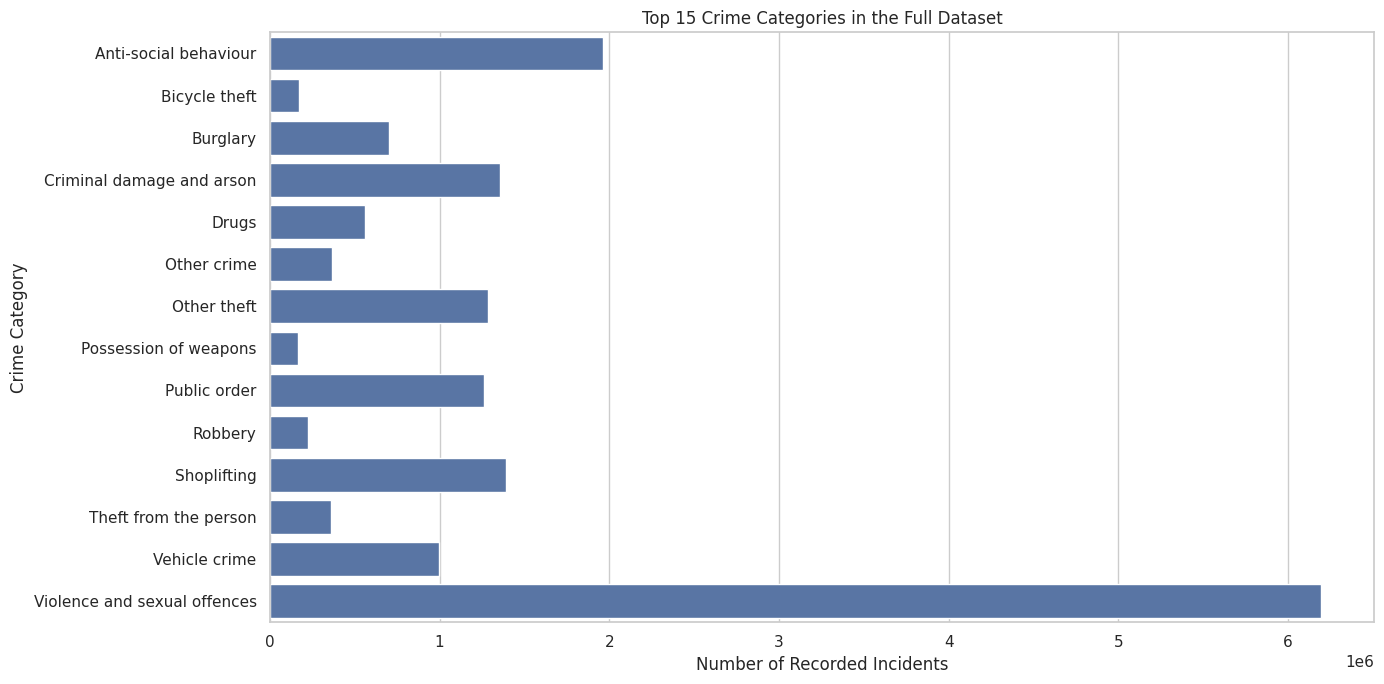

In [29]:
# Check if crime_counts DataFrame is not empty before plotting
if not crime_counts.empty:

    # Set figure size for better readability of the plot
    plt.figure(figsize=(14, 7))

    # Create a horizontal bar plot for top 15 crime categories
    sns.barplot(
        data=crime_counts.head(15),
        x='Count',
        y='Crime type'
    )

    # Add title to the plot
    plt.title('Top 15 Crime Categories in the Full Dataset')

    # Label x-axis
    plt.xlabel('Number of Recorded Incidents')

    # Label y-axis
    plt.ylabel('Crime Category')

    # Adjust layout to prevent overlapping elements
    plt.tight_layout()

    # Display the plot
    plt.show()

In [30]:
# Check if crime_counts DataFrame is not empty before creating the plot
if not crime_counts.empty:

    # Create an interactive bar chart using Plotly
    # Shows top 20 crime categories with percentage labels on bars
    fig = px.bar(
        crime_counts.head(20),               # Select top 20 crime categories
        x='Crime type',                       # Crime categories on x-axis
        y='Count',                            # Number of incidents on y-axis
        title='Top 20 Crime Categories (Interactive)',  # Chart title
        text='Percentage'                    # Display percentage on each bar
    )

    # Customize axis labels for better readability
    fig.update_layout(
        xaxis_title='Crime Category',
        yaxis_title='Count'
    )

    # Render the interactive plot
    fig.show()

In [31]:
# Check if 'Last outcome category' column exists in the dataset
if 'Last outcome category' in df.columns:

    # Convert column to string, replace literal 'nan' strings with actual NaN values,
    # then compute frequency counts including missing values
    outcome_counts = (
        df['Last outcome category']
        .astype(str)
        .replace('nan', np.nan)
        .value_counts(dropna=False)
        .rename_axis('Last outcome category')
        .reset_index(name='Count')
    )

    # Display top 20 outcome categories for analysis
    display(outcome_counts.head(20))

,Last outcome category,Count
0,Investigation complete; no suspect identified,5774878
1,Unable to prosecute suspect,5355610
2,NaN,2327604
3,Status update unavailable,1026975
4,Court result unavailable,810606
5,Under investigation,459479
6,Local resolution,412028
7,Awaiting court outcome,282788
8,Action to be taken by another organisation,200031
9,Offender given a caution,114484


## 11. Temporal Analysis


In [32]:
# Check if 'Month' column exists in the dataset
if 'Month' in df.columns:

    # Group data by Month and count number of crime records per month
    monthly_trend = (
        df.groupby('Month')
        .size()
        .reset_index(name='Crime_Count')
        .sort_values('Month')  # Ensure chronological order
    )

    # Display first few rows of monthly trend data
    display(monthly_trend.head())

else:
    # Create empty DataFrame if Month column is not available
    monthly_trend = pd.DataFrame()

,Month,Crime_Count
0,2023-02-01,459180
1,2023-03-01,502078
2,2023-04-01,482345
3,2023-05-01,504637
4,2023-06-01,512414


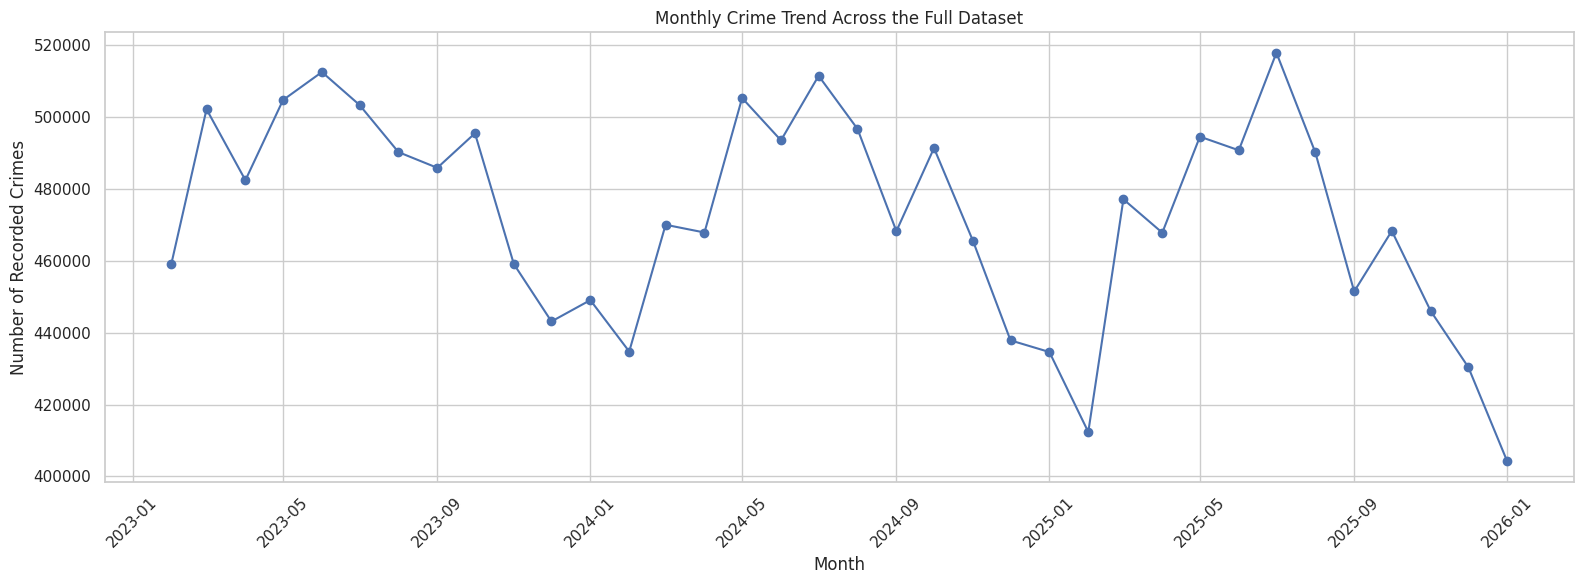

In [33]:
# Check if monthly trend data is available before plotting
if not monthly_trend.empty:

    # Set figure size for better visualization of time-series trend
    plt.figure(figsize=(16, 6))

    # Plot line graph showing crime counts over time (monthly trend)
    plt.plot(
        monthly_trend['Month'],        # X-axis: time (Month)
        monthly_trend['Crime_Count'],  # Y-axis: number of crimes
        marker='o'                     # Show data points clearly on the line
    )

    # Add plot title
    plt.title('Monthly Crime Trend Across the Full Dataset')

    # Label X-axis
    plt.xlabel('Month')

    # Label Y-axis
    plt.ylabel('Number of Recorded Crimes')

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Adjust layout to prevent overlapping elements
    plt.tight_layout()

    # Display the plot
    plt.show()

,Year,Crime_Count
0,2023,5337379
1,2024,5690936
2,2025,5580753
3,2026,404208


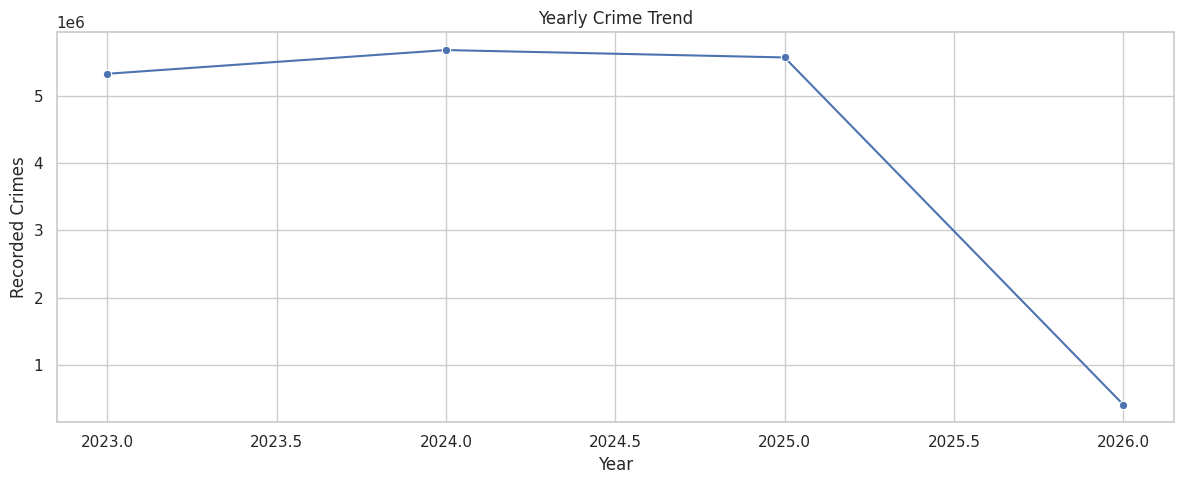

In [34]:
# Check if 'Year' column exists before performing yearly trend analysis
if 'Year' in df.columns:

    # Group data by Year and count total crimes per year
    yearly_trend = (
        df.groupby('Year')
        .size()
        .reset_index(name='Crime_Count')
        .sort_values('Year')
    )

    # Display yearly trend table
    display(yearly_trend)

    # Create figure for yearly trend visualization
    plt.figure(figsize=(12, 5))

    # Plot line chart showing crime trend over years
    sns.lineplot(
        data=yearly_trend,
        x='Year',
        y='Crime_Count',
        marker='o'
    )

    # Add chart title
    plt.title('Yearly Crime Trend')

    # Label x-axis
    plt.xlabel('Year')

    # Label y-axis
    plt.ylabel('Recorded Crimes')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Display plot
    plt.show()

Month_Name,January,February,March,April,May,June,July,August,September,October,November,December
Year,,,,,,,,,,,,
2023,NaN,"459,180.0000","502,078.0000","482,345.0000","504,637.0000","512,414.0000","503,258.0000","490,159.0000","485,786.0000","495,391.0000","459,046.0000","443,085.0000"
2024,"449,017.0000","434,726.0000","469,961.0000","467,810.0000","505,196.0000","493,425.0000","511,368.0000","496,604.0000","468,186.0000","491,281.0000","465,535.0000","437,827.0000"
2025,"434,587.0000","412,362.0000","477,041.0000","467,754.0000","494,455.0000","490,669.0000","517,774.0000","490,072.0000","451,422.0000","468,251.0000","445,992.0000","430,374.0000"
2026,"404,208.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


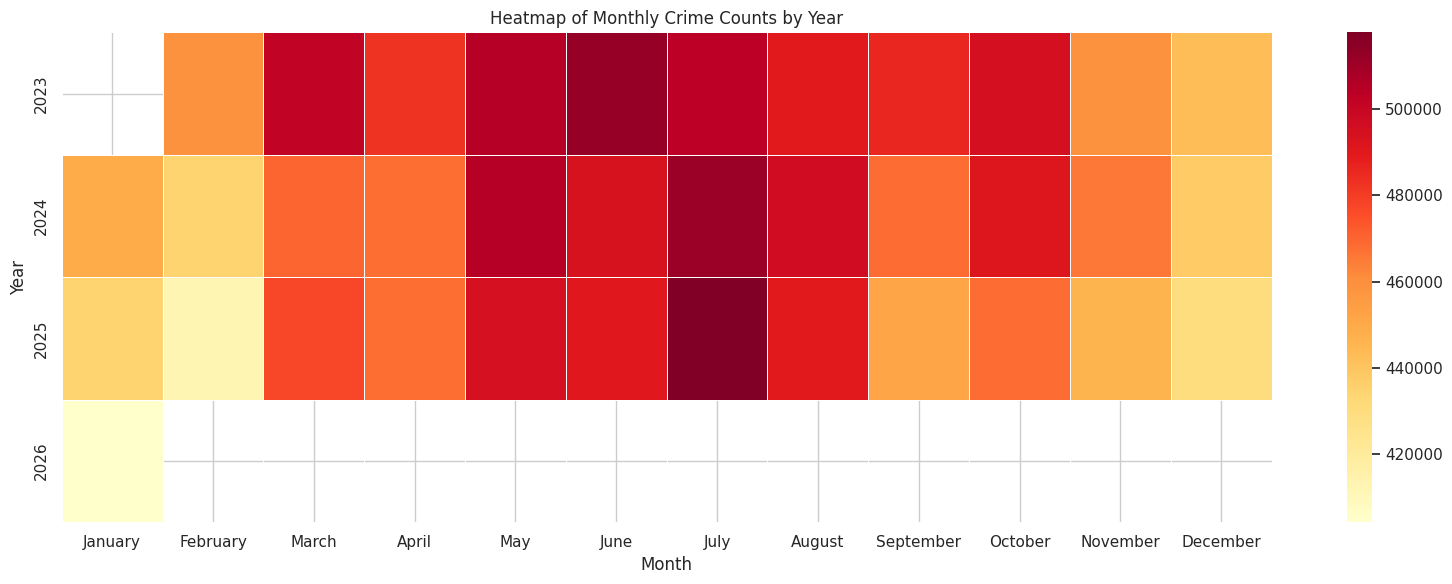

In [35]:
# Check if required time-based columns exist for seasonal heatmap analysis
if {'Year', 'Month_Name', 'Month_Num'}.issubset(df.columns):

    # Create correct month ordering based on numeric month values (1–12)
    # This ensures months appear in chronological order instead of alphabetical
    month_order = (
        df[['Month_Num', 'Month_Name']]
        .drop_duplicates()
        .sort_values('Month_Num')['Month_Name']
        .tolist()
    )

    # Create a Year vs Month pivot table showing total crime counts
    seasonal_month_matrix = (
        df.groupby(['Year', 'Month_Name'])
        .size()
        .reset_index(name='Crime_Count')
        .pivot(index='Year', columns='Month_Name', values='Crime_Count')
        .reindex(columns=month_order)  # enforce correct month order
    )

    # Display first few rows of the matrix
    display(seasonal_month_matrix.head())

    # Set figure size for heatmap visualization
    plt.figure(figsize=(16, 6))

    # Plot heatmap showing crime intensity by month and year
    sns.heatmap(
        seasonal_month_matrix,
        cmap='YlOrRd',   # color palette (yellow → red intensity)
        linewidths=0.5   # grid lines between cells
    )

    # Add plot title
    plt.title('Heatmap of Monthly Crime Counts by Year')

    # Label axes
    plt.xlabel('Month')
    plt.ylabel('Year')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Display heatmap
    plt.show()

,Season,Crime_Count
2,Summer,4505743
1,Spring,4371277
0,Autumn,4230890
3,Winter,3905366


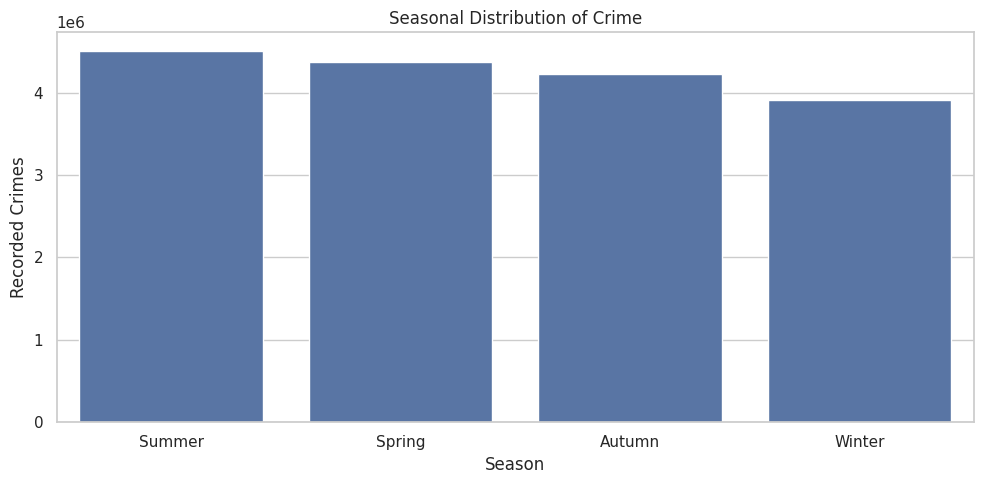

In [36]:
# Check if 'Season' column exists before performing seasonal analysis
if 'Season' in df.columns:

    # Group data by Season and count total crimes in each season
    season_counts = (
        df.groupby('Season')
        .size()
        .reset_index(name='Crime_Count')
        .sort_values('Crime_Count', ascending=False)
    )

    # Display seasonal crime distribution table
    display(season_counts)

    # Set figure size for visualization
    plt.figure(figsize=(10, 5))

    # Create bar plot for seasonal crime distribution
    sns.barplot(
        data=season_counts,
        x='Season',
        y='Crime_Count',
        order=season_counts['Season']  # maintain sorted order
    )

    # Add plot title
    plt.title('Seasonal Distribution of Crime')

    # Label x-axis
    plt.xlabel('Season')

    # Label y-axis
    plt.ylabel('Recorded Crimes')

    # Adjust layout to avoid overlapping elements
    plt.tight_layout()

    # Show plot
    plt.show()

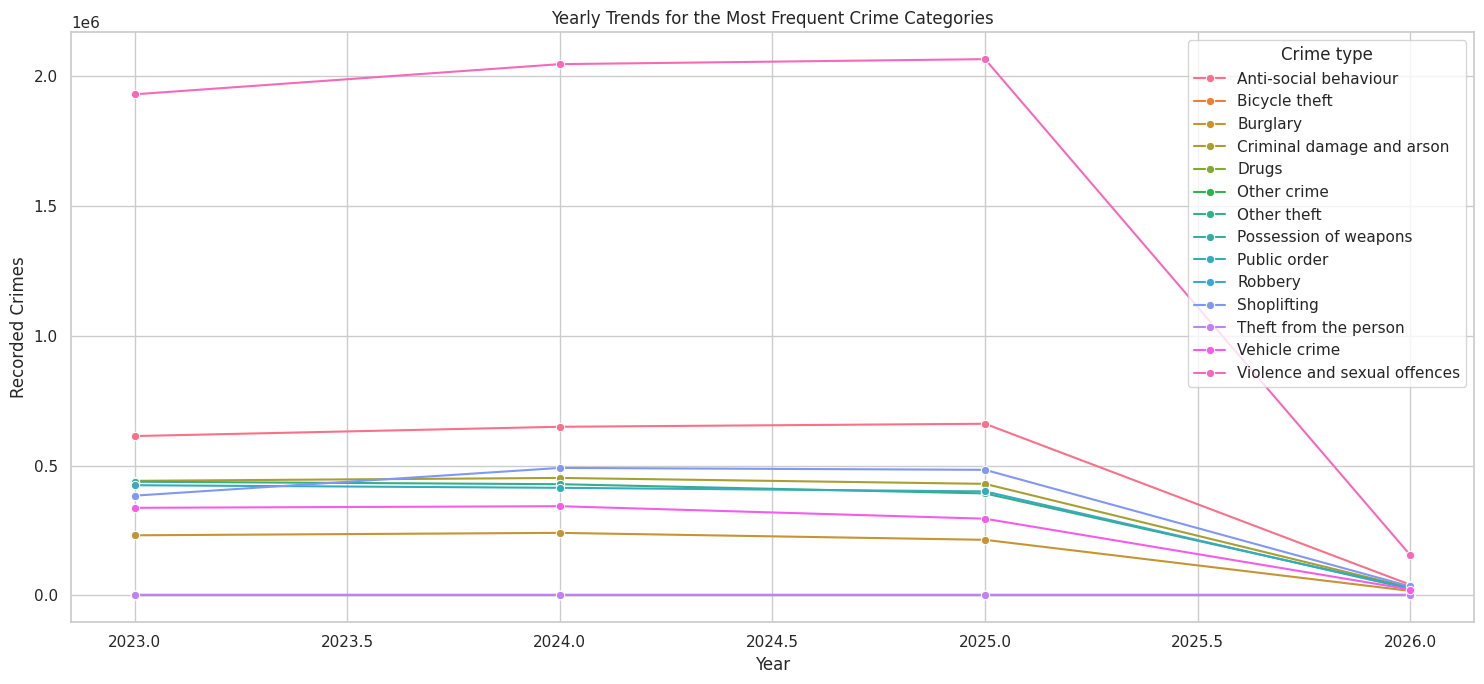

In [37]:
# Check if required columns exist before performing trend analysis
if {'Year', 'Crime type'}.issubset(df.columns):

    # Identify top 8 most frequent crime categories in the dataset
    top_categories = (
        df['Crime type']
        .value_counts()
        .head(8)
        .index
        .tolist()
    )

    # Filter dataset to only include top crime categories
    # Then group by Year and Crime type to compute yearly counts
    year_type = (
        df[df['Crime type'].isin(top_categories)]
        .groupby(['Year', 'Crime type'])
        .size()
        .reset_index(name='Crime_Count')
    )

    # Create figure for multi-line trend visualization
    plt.figure(figsize=(15, 7))

    # Plot yearly trend lines for each top crime category
    sns.lineplot(
        data=year_type,
        x='Year',
        y='Crime_Count',
        hue='Crime type',
        marker='o'
    )

    # Add title to the chart
    plt.title('Yearly Trends for the Most Frequent Crime Categories')

    # Label x-axis
    plt.xlabel('Year')

    # Label y-axis
    plt.ylabel('Recorded Crimes')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Display plot
    plt.show()

## 12. Spatial Analysis


In [38]:
# Check if both coordinate columns exist before generating spatial summary
if {'Longitude', 'Latitude'}.issubset(df.columns):

    # Create a summary table to understand coordinate data availability
    coord_summary = pd.DataFrame({
        # Define metric names for clarity
        'metric': [
            'Total rows',
            'Rows with both coordinates',
            'Rows missing any coordinate'
        ],

        # Compute values for each metric
        'value': [
            len(df),  # total number of records
            df[['Longitude', 'Latitude']].dropna().shape[0],  # rows with valid coordinates
            len(df) - df[['Longitude', 'Latitude']].dropna().shape[0]  # missing coordinate rows
        ]
    })

    # Calculate percentage contribution of each metric relative to total dataset size
    coord_summary['pct'] = (coord_summary['value'] / len(df) * 100).round(2)

    # Display coordinate completeness summary
    display(coord_summary)

,metric,value,pct
0,Total rows,17013276,100.0000
1,Rows with both coordinates,16749218,98.4500
2,Rows missing any coordinate,264058,1.5500


,Falls within,Count
0,Metropolitan Police Service,3091383
1,West Midlands Police,1005950
2,West Yorkshire Police,917954
3,Thames Valley Police,585911
4,Avon and Somerset Constabulary,542042
5,Kent Police,531857
6,South Yorkshire Police,512950
7,Hampshire Constabulary,498860
8,Northumbria Police,495086
9,Lancashire Constabulary,493216


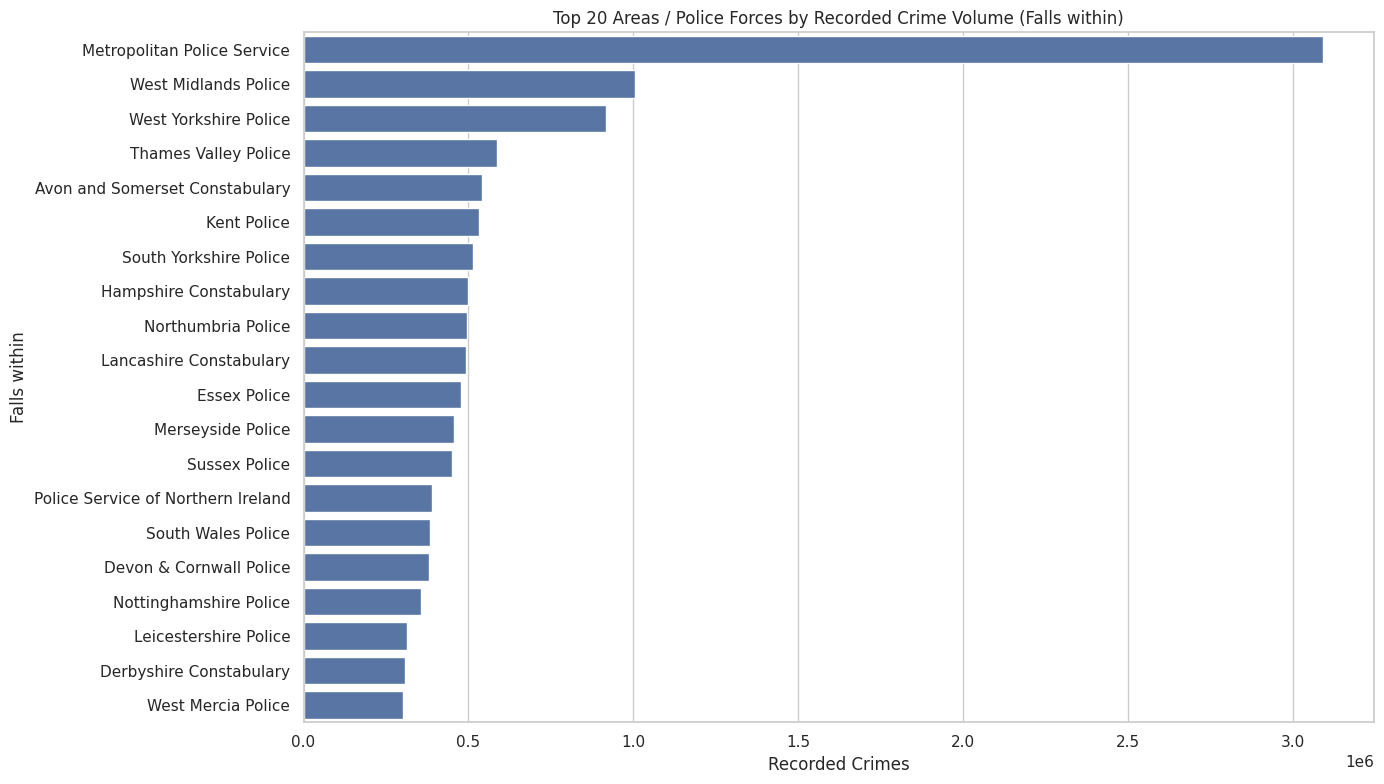

In [39]:
# Initialize variable to determine which police force-related column is available
force_col = None

# Check available columns and select the first matching one
# Priority is given to 'Falls within', then 'Reported by'
for c in ['Falls within', 'Reported by']:
    if c in df.columns:
        force_col = c
        break


# If a valid police force column is found, perform analysis
if force_col is not None:

    # Calculate frequency of each police force / jurisdiction area
    force_counts = (
        df[force_col]
        .astype(str)  # ensure consistent string type
        .value_counts(dropna=False)
        .rename_axis(force_col)
        .reset_index(name='Count')
    )

    # Display top 20 forces/areas by number of recorded crimes
    display(force_counts.head(20))

    # Create bar plot for top 20 police forces/areas
    plt.figure(figsize=(14, 8))

    sns.barplot(
        data=force_counts.head(20),
        x='Count',
        y=force_col
    )

    # Add title to plot
    plt.title(f'Top 20 Areas / Police Forces by Recorded Crime Volume ({force_col})')

    # Label axes
    plt.xlabel('Recorded Crimes')
    plt.ylabel(force_col)

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show plot
    plt.show()

else:
    # Create empty DataFrame if no relevant column exists
    force_counts = pd.DataFrame()

In [40]:
# Check if 'LSOA name' column exists before performing geographic area analysis
if 'LSOA name' in df.columns:

    # Clean and process LSOA names:
    # - Convert to string
    # - Replace string 'nan' with actual NaN
    # - Drop missing values
    # - Count occurrences of each LSOA
    lsoa_counts = (
        df['LSOA name']
        .astype(str)
        .replace('nan', np.nan)
        .dropna()
        .value_counts()
        .rename_axis('LSOA name')
        .reset_index(name='Count')
    )

    # Display top 20 LSOA areas with highest recorded crime counts
    display(lsoa_counts.head(20))

,LSOA name,Count
0,Westminster 013G,40280
1,Westminster 013B,32224
2,Westminster 018A,30388
3,Leeds 111B,22849
4,City of London 001F,21406
5,Westminster 018C,18295
6,Birmingham 138A,16632
7,Liverpool 060C,15708
8,Cardiff 032H,15704
9,Hillingdon 031A,13712


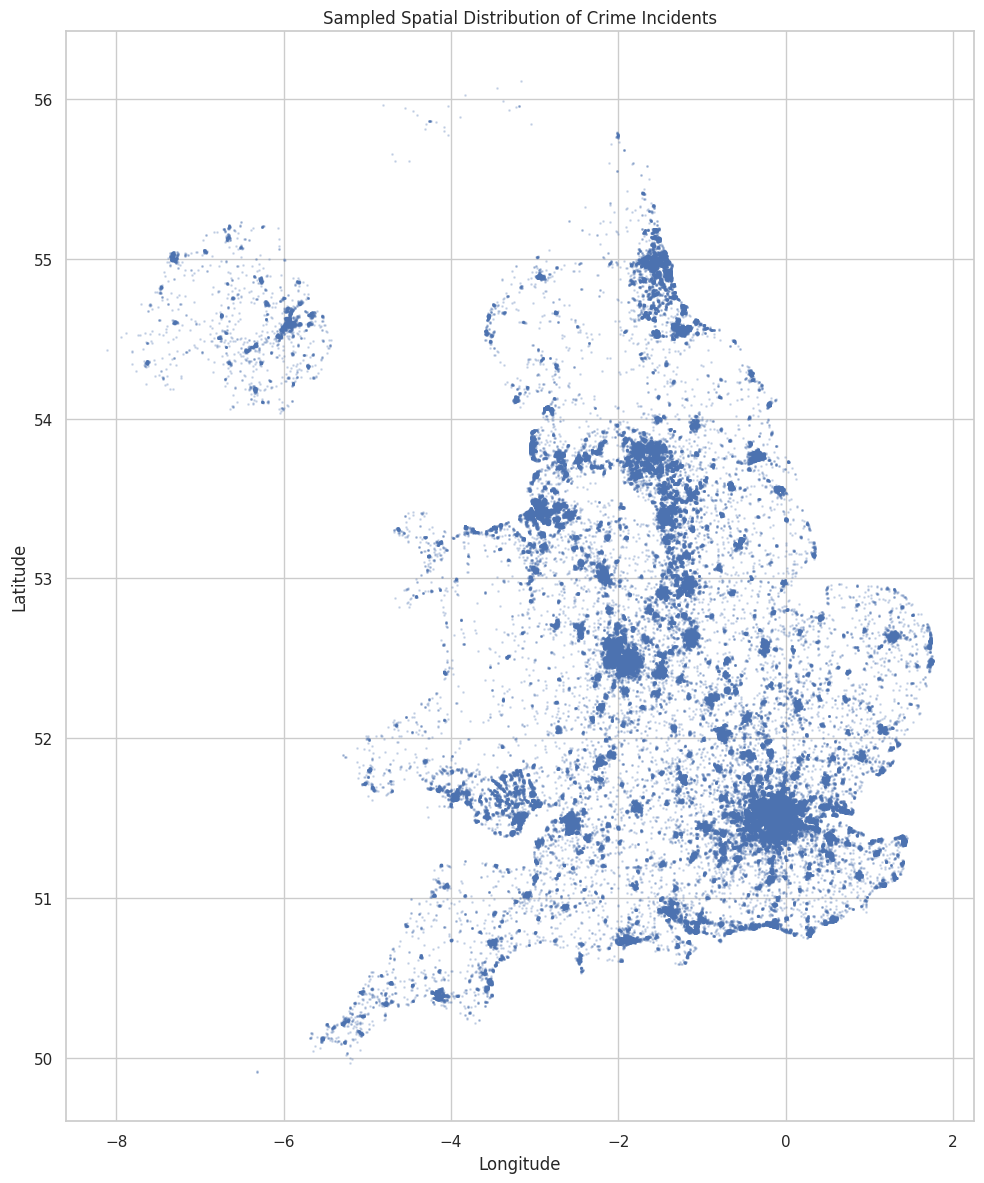

In [41]:
# Check if both coordinate columns exist before creating spatial visualization
if {'Longitude', 'Latitude'}.issubset(df.columns):

    # Extract only valid coordinate pairs (remove missing values)
    geo_sample = df[['Longitude', 'Latitude']].dropna()

    # If dataset is too large, randomly sample up to 200,000 points for faster plotting
    if len(geo_sample) > 200_000:
        geo_sample = geo_sample.sample(200_000, random_state=42)

    # Set figure size for spatial scatter plot
    plt.figure(figsize=(10, 12))

    # Plot geographic distribution of crime incidents
    # s=1 makes points very small for dense data visualization
    # alpha controls transparency to reduce overplotting
    plt.scatter(
        geo_sample['Longitude'],
        geo_sample['Latitude'],
        s=1,
        alpha=0.2
    )

    # Add plot title
    plt.title('Sampled Spatial Distribution of Crime Incidents')

    # Label x-axis
    plt.xlabel('Longitude')

    # Label y-axis
    plt.ylabel('Latitude')

    # Adjust layout for clean appearance
    plt.tight_layout()

    # Display plot
    plt.show()

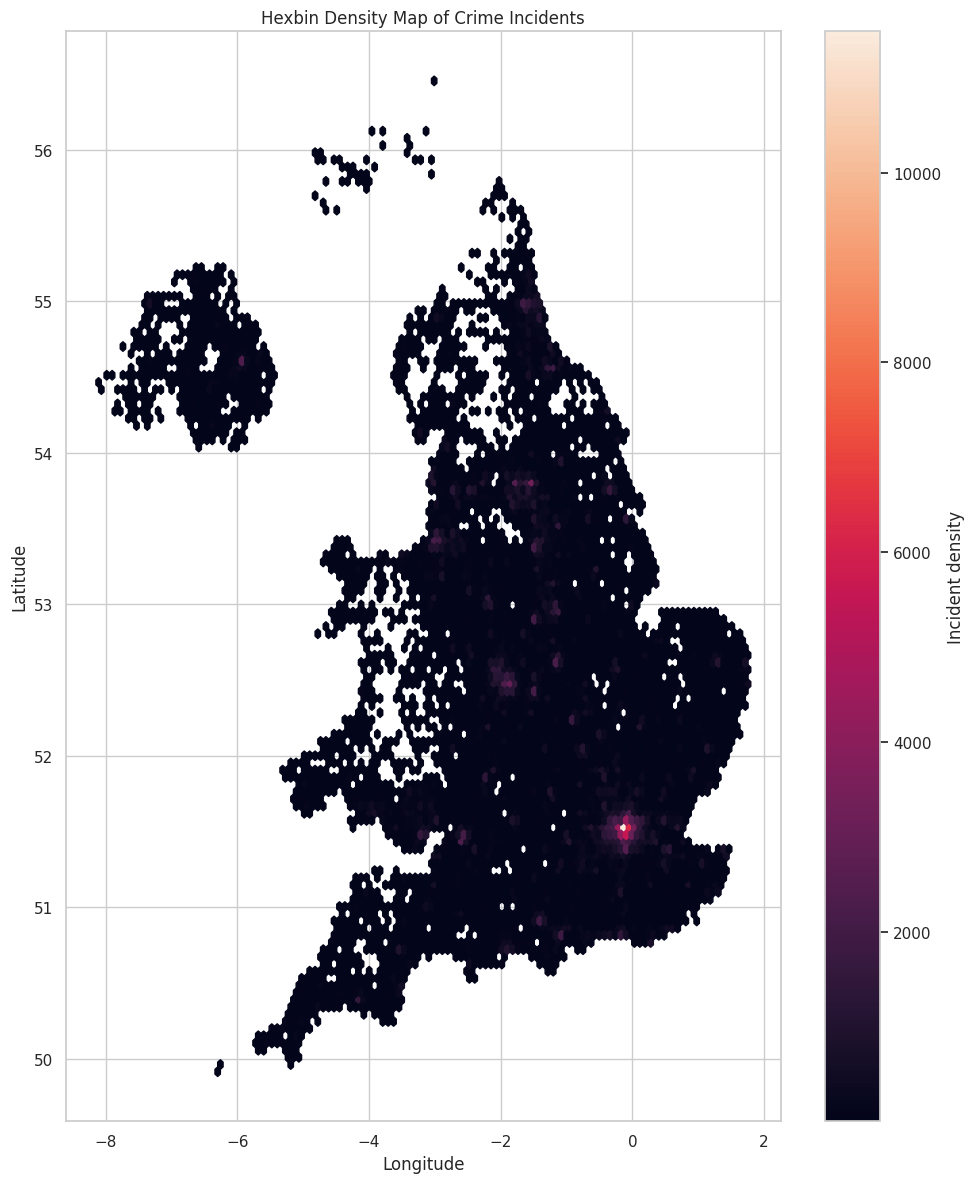

In [42]:
# Check if both coordinate columns exist before creating a density-based spatial plot
if {'Longitude', 'Latitude'}.issubset(df.columns):

    # Extract valid coordinate pairs by removing missing values
    geo_sample = df[['Longitude', 'Latitude']].dropna()

    # If dataset is very large, randomly sample up to 500,000 points for efficiency
    if len(geo_sample) > 500_000:
        geo_sample = geo_sample.sample(500_000, random_state=42)

    # Set figure size for hexbin density visualization
    plt.figure(figsize=(10, 12))

    # Create hexbin plot to visualize spatial density of crime incidents
    # gridsize controls resolution of hexagonal bins
    # mincnt=1 ensures only bins with at least one point are shown
    plt.hexbin(
        geo_sample['Longitude'],
        geo_sample['Latitude'],
        gridsize=120,
        mincnt=1
    )

    # Add color bar to represent density scale
    plt.colorbar(label='Incident density')

    # Add plot title
    plt.title('Hexbin Density Map of Crime Incidents')

    # Label x-axis
    plt.xlabel('Longitude')

    # Label y-axis
    plt.ylabel('Latitude')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Display the plot
    plt.show()

In [43]:
# Check if required columns exist for interactive spatial visualization
if {'Longitude', 'Latitude', 'Crime type'}.issubset(df.columns):

    # Extract only relevant columns and remove rows with missing values
    map_sample = df[['Longitude', 'Latitude', 'Crime type']].dropna()

    # If dataset is large, randomly sample up to 20,000 rows for performance
    if len(map_sample) > 20_000:
        map_sample = map_sample.sample(20_000, random_state=42)

    # Create interactive map using Plotly Mapbox
    # Points are colored by crime type for category-wise spatial distribution
    fig = px.scatter_mapbox(
        map_sample,
        lat='Latitude',        # Latitude for spatial positioning
        lon='Longitude',       # Longitude for spatial positioning
        color='Crime type',    # Color encoding by crime category
        zoom=4,                # Initial zoom level for UK-wide view
        height=700,            # Map height in pixels
        title='Interactive Spatial Sample of Crime Incidents'
    )

    # Set map style to OpenStreetMap (no API key required)
    fig.update_layout(mapbox_style='open-street-map')

    # Display interactive map
    fig.show()

## 13. Spatio-Temporal Cross Analysis


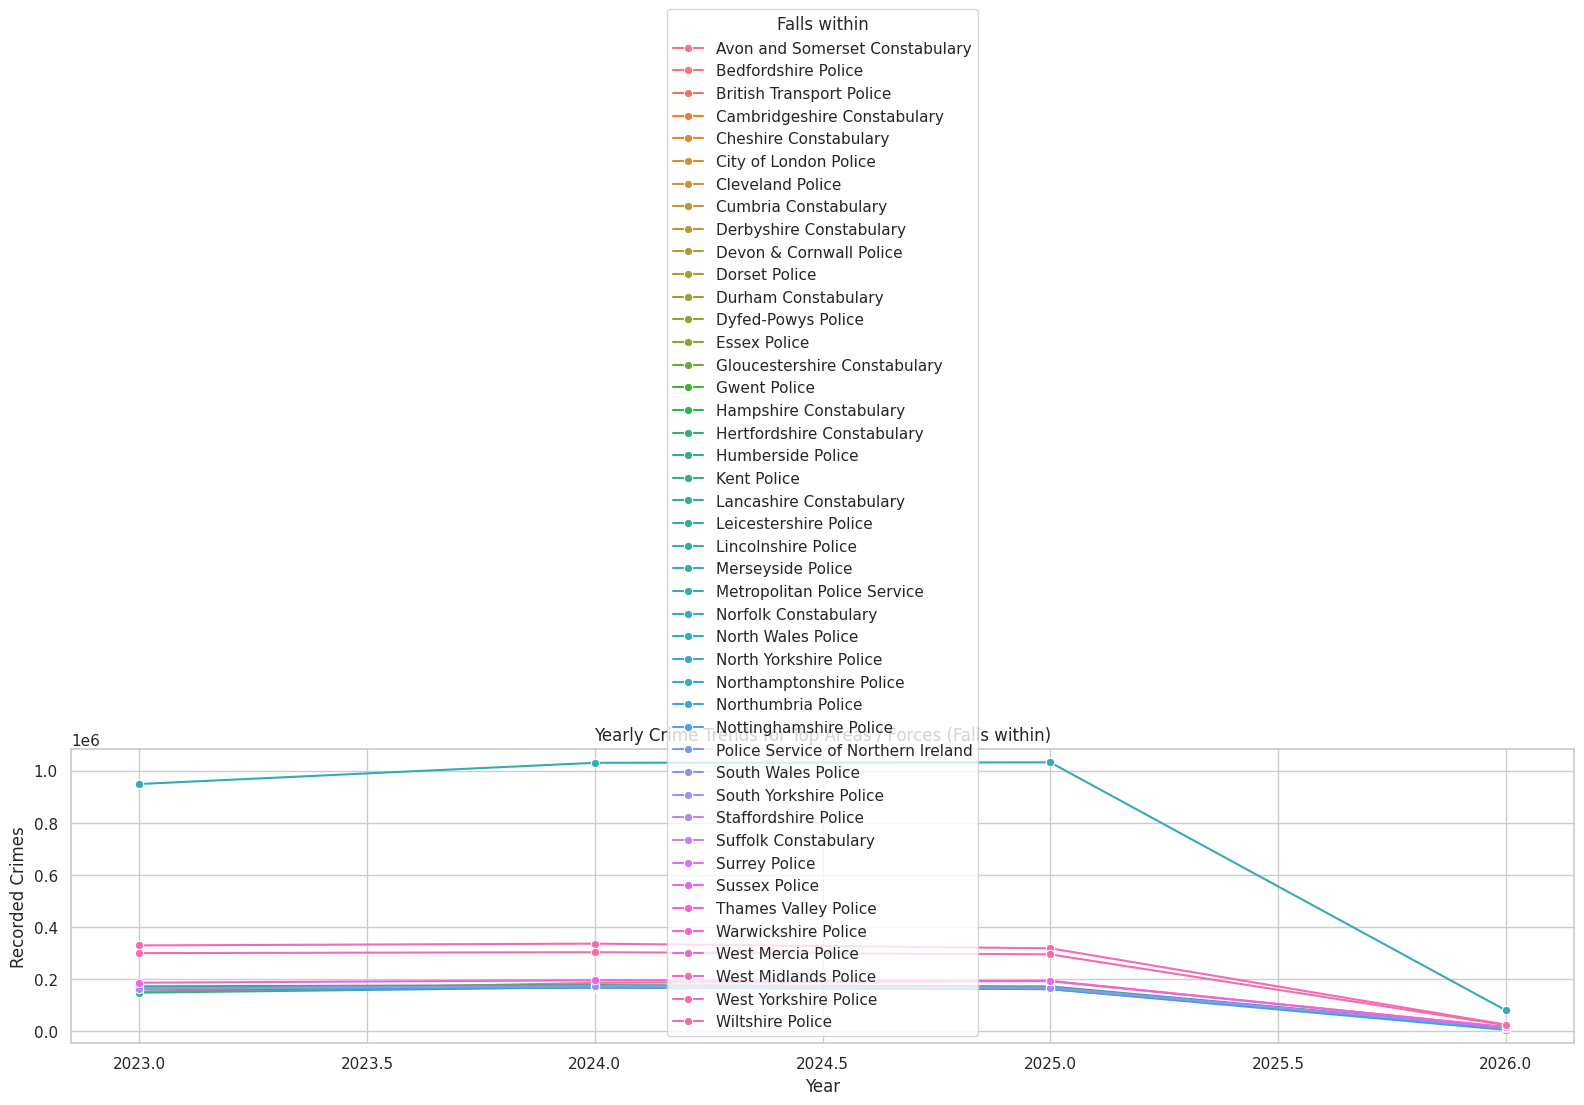

In [44]:
# Check if both required elements exist:
# - force_col (selected police force / area column)
# - 'Year' column for time-based trend analysis
if force_col is not None and 'Year' in df.columns:

    # Group data by force/area and year, and count total crimes per combination
    force_year = (
        df.groupby([force_col, 'Year'])
        .size()
        .reset_index(name='Crime_Count')
    )

    # Identify top 10 most frequent forces/areas overall
    top_forces = (
        df[force_col]
        .astype(str)
        .value_counts()
        .head(10)
        .index
        .tolist()
    )

    # Filter dataset to include only top forces for clearer visualization
    force_year_top = force_year[
        force_year[force_col].astype(str).isin(top_forces)
    ]

    # Set figure size for trend visualization
    plt.figure(figsize=(16, 8))

    # Plot yearly trend lines for each top force/area
    sns.lineplot(
        data=force_year_top,
        x='Year',
        y='Crime_Count',
        hue=force_col,
        marker='o'
    )

    # Add chart title
    plt.title(f'Yearly Crime Trends for Top Areas / Forces ({force_col})')

    # Label axes
    plt.xlabel('Year')
    plt.ylabel('Recorded Crimes')

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Display plot
    plt.show()

Season,Autumn,Spring,Summer,Winter
Crime type,,,,
Anti-social behaviour,479225,517056,571392,398067
Bicycle theft,0,0,0,0
Burglary,179313,175112,174240,175452
Criminal damage and arson,333423,352563,360456,307277
Drugs,143435,138059,139992,138539
Other crime,93121,94778,91969,88192
Other theft,320525,326381,337709,303090
Possession of weapons,0,0,0,0
Public order,307301,340131,350782,266520


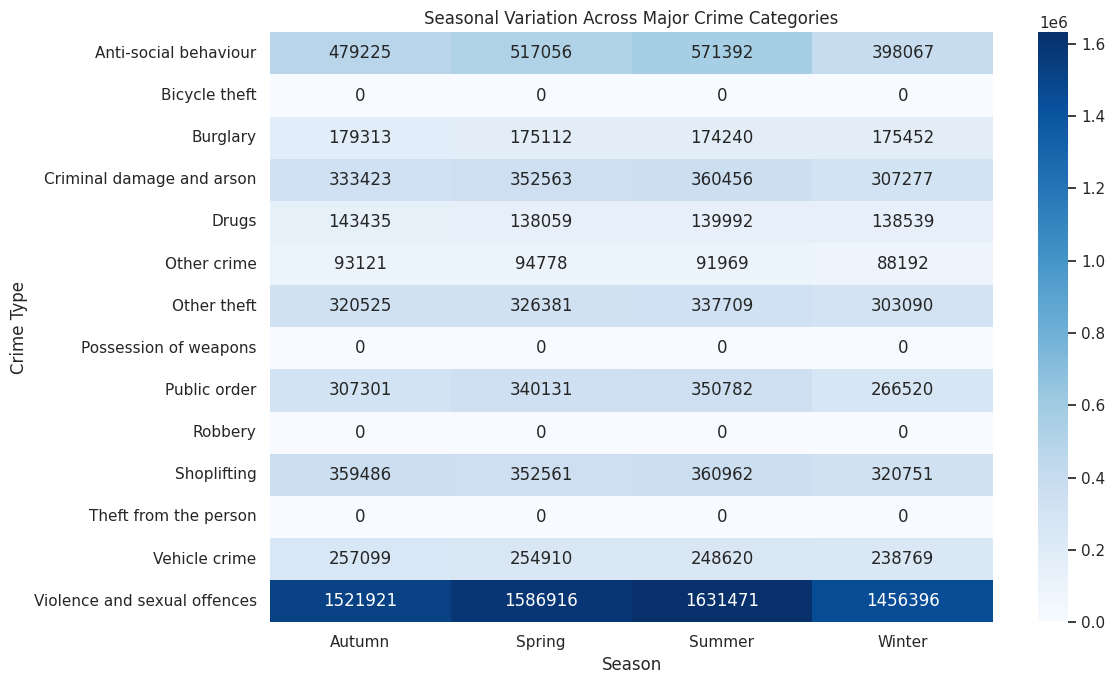

In [45]:
# Check if both required columns exist for seasonal crime pattern analysis
if {'Crime type', 'Season'}.issubset(df.columns):

    # Identify top 10 most frequent crime categories in the dataset
    top_categories = (
        df['Crime type']
        .value_counts()
        .head(10)
        .index
        .tolist()
    )

    # Filter dataset to include only top crime categories
    # Then group by Crime type and Season to compute counts
    crime_season = (
        df[df['Crime type'].isin(top_categories)]
        .groupby(['Crime type', 'Season'])
        .size()
        .reset_index(name='Crime_Count')
    )

    # Pivot table to reshape data into matrix form (Crime type × Season)
    crime_season_pivot = (
        crime_season
        .pivot(index='Crime type', columns='Season', values='Crime_Count')
        .fillna(0)  # Replace missing combinations with 0
    )

    # Display pivot table for inspection
    display(crime_season_pivot)

    # Set figure size for heatmap visualization
    plt.figure(figsize=(12, 7))

    # Create heatmap showing seasonal variation in crime categories
    sns.heatmap(
        crime_season_pivot,
        cmap='Blues',
        annot=True,   # show values in each cell
        fmt='.0f'     # format as integer values
    )

    # Add plot title
    plt.title('Seasonal Variation Across Major Crime Categories')

    # Label axes
    plt.xlabel('Season')
    plt.ylabel('Crime Type')

    # Adjust layout for clean visualization
    plt.tight_layout()

    # Display heatmap
    plt.show()

Crime type,Anti-social behaviour,Bicycle theft,Burglary,Criminal damage and arson,Drugs,Other crime,Other theft,Possession of weapons,Public order,Robbery,Shoplifting,Theft from the person,Vehicle crime,Violence and sexual offences
Year,,,,,,,,,,,,,,
2023,613748,0,231599,441313,153591,101069,437927,0,424383,0,384238,0,337435,1929864
2024,649572,0,240943,452523,178549,126113,428396,0,414479,0,491093,0,343641,2046028
2025,661146,0,214164,429729,210285,130534,392843,0,400642,0,483747,0,295482,2065295
2026,41274,0,17411,30154,17600,10344,28539,0,25230,0,34682,0,22840,155517


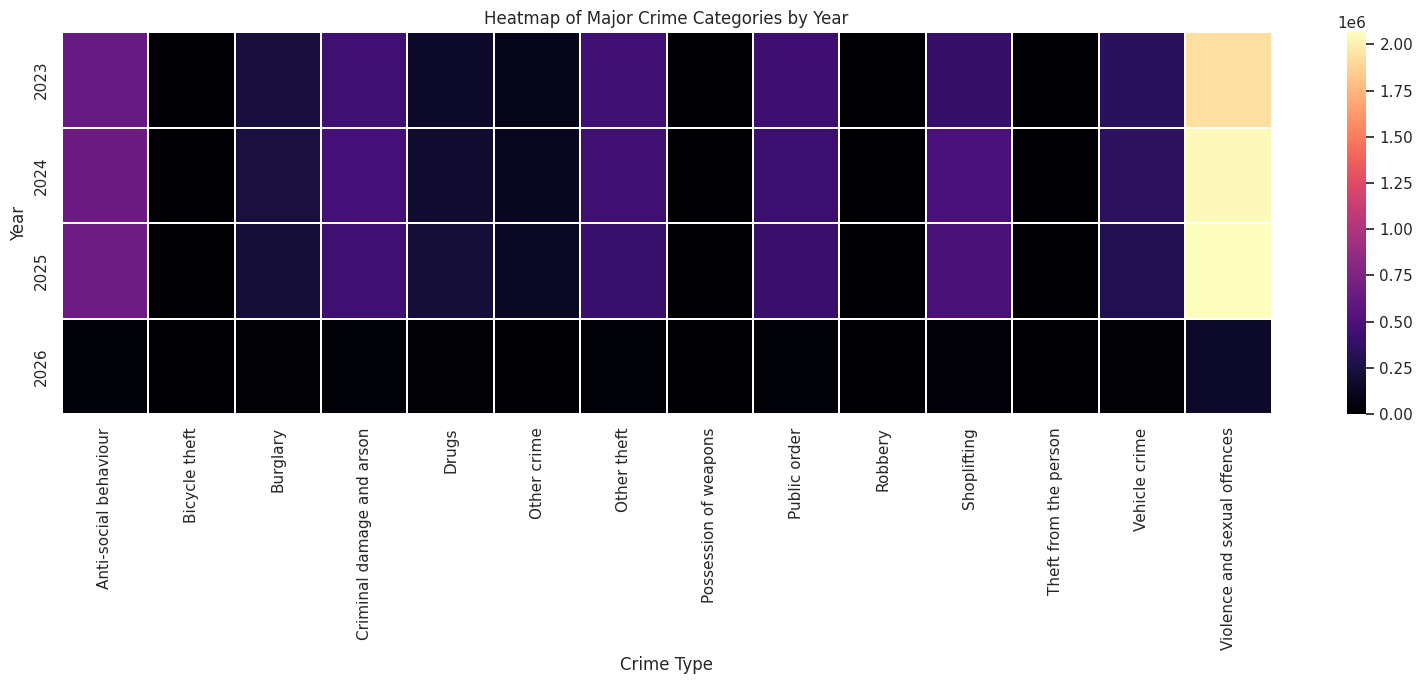

In [46]:
# Check if required columns exist for year-wise crime category heatmap analysis
if {'Crime type', 'Year'}.issubset(df.columns):

    # Identify top 10 most frequent crime categories
    top_categories = (
        df['Crime type']
        .value_counts()
        .head(10)
        .index
        .tolist()
    )

    # Filter dataset to include only top crime categories
    # Then compute yearly counts per crime type
    crosstab_year_type = (
        df[df['Crime type'].isin(top_categories)]
        .groupby(['Year', 'Crime type'])
        .size()
        .reset_index(name='Crime_Count')
        .pivot(index='Year', columns='Crime type', values='Crime_Count')
        .fillna(0)  # Replace missing values with 0
    )

    # Display first few rows of the pivot table
    display(crosstab_year_type.head())

    # Set figure size for heatmap visualization
    plt.figure(figsize=(16, 7))

    # Create heatmap to show distribution of major crime types over years
    sns.heatmap(
        crosstab_year_type,
        cmap='magma',      # color map for intensity visualization
        linewidths=0.3     # grid lines for better separation
    )

    # Add plot title
    plt.title('Heatmap of Major Crime Categories by Year')

    # Label axes
    plt.xlabel('Crime Type')
    plt.ylabel('Year')

    # Adjust layout for clean display
    plt.tight_layout()

    # Show plot
    plt.show()

## 14. Missingness and Data Completeness by Key Analytical Variables


In [47]:
# Select only important key columns that actually exist in the dataset
# This avoids errors from missing columns in different CSV files
key_cols = [
    c for c in [
        'Crime ID', 'Month', 'Longitude', 'Latitude', 'Location',
        'LSOA code', 'LSOA name', 'Crime type', 'Last outcome category',
        'Falls within', 'Reported by'
    ]
    if c in df.columns
]


# Create a data quality/completeness summary for key columns
completeness = pd.DataFrame({
    # Column names being evaluated
    'column': key_cols,

    # Count of non-missing values per column
    'non_null_count': [df[c].notna().sum() for c in key_cols],

    # Count of missing values per column
    'missing_count': [df[c].isna().sum() for c in key_cols],

    # Percentage of missing values per column
    'missing_pct': [
        (df[c].isna().mean() * 100)
        for c in key_cols
    ]
})

# Sort columns by highest missing percentage first (worst data quality on top)
completeness = completeness.sort_values('missing_pct', ascending=False)


# Display completeness report
display(completeness)

,column,non_null_count,missing_count,missing_pct
8,Last outcome category,14685672,2327604,13.6811
0,Crime ID,14978791,2034485,11.9582
6,LSOA name,16361437,651839,3.8314
5,LSOA code,16361437,651839,3.8314
2,Longitude,16749218,264058,1.5521
3,Latitude,16749218,264058,1.5521
1,Month,17013276,0,0.0000
4,Location,17013276,0,0.0000
7,Crime type,17013276,0,0.0000
9,Falls within,17013276,0,0.0000


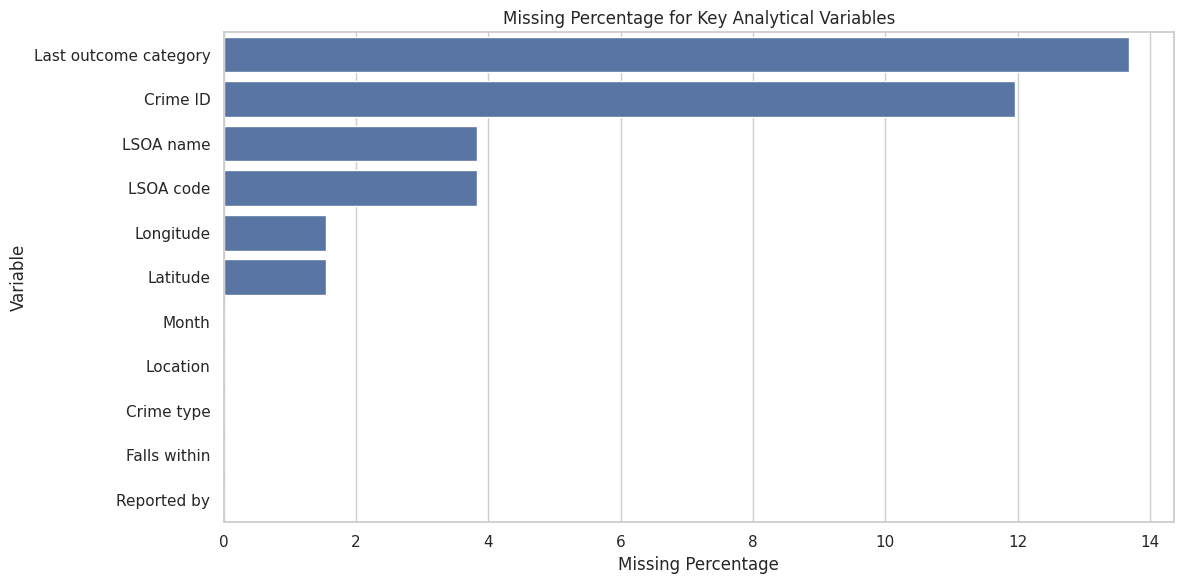

In [48]:
# Set figure size for better readability of missing value visualization
plt.figure(figsize=(12, 6))

# Create a horizontal bar plot showing missing percentage for each key variable
sns.barplot(
    data=completeness,
    x='missing_pct',   # Percentage of missing values
    y='column'         # Column names (variables)
)

# Add plot title
plt.title('Missing Percentage for Key Analytical Variables')

# Label x-axis
plt.xlabel('Missing Percentage')

# Label y-axis
plt.ylabel('Variable')

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()

## 15. Preparation for Spatial Clustering (No Clustering Yet)


In [49]:
# Select only columns that are relevant for clustering and actually exist in the dataset
cluster_ready_cols = [
    c for c in [
        'Month', 'Year', 'Month_Num', 'Season', 'Longitude', 'Latitude',
        'Crime type', 'LSOA name', 'Falls within', 'Reported by'
    ]
    if c in df.columns
]


# Create a clustering-ready dataset by selecting relevant columns
cluster_ready = df[cluster_ready_cols].copy()

# Remove rows where essential geographic coordinates are missing
# (clustering spatial data requires valid longitude/latitude)
cluster_ready = cluster_ready.dropna(
    subset=[c for c in ['Longitude', 'Latitude'] if c in df.columns]
)


# Print final dataset shape after cleaning for clustering
print('Cluster-ready point dataset shape:', cluster_ready.shape)

# Display first few rows to verify structure
display(cluster_ready.head())

Cluster-ready point dataset shape: (16749218, 10)


,Month,Year,Month_Num,Season,Longitude,Latitude,Crime type,LSOA name,Falls within,Reported by
0,2023-02-01,2023,2,Winter,-1.5637,53.5504,Vehicle crime,Barnsley 016C,Avon and Somerset Constabulary,Avon and Somerset Constabulary
1,2023-02-01,2023,2,Winter,-2.4911,51.4250,Anti-social behaviour,Bath and North East Somerset 001A,Avon and Somerset Constabulary,Avon and Somerset Constabulary
2,2023-02-01,2023,2,Winter,-2.5093,51.4097,Anti-social behaviour,Bath and North East Somerset 001A,Avon and Somerset Constabulary,Avon and Somerset Constabulary
3,2023-02-01,2023,2,Winter,-2.4929,51.4227,Other theft,Bath and North East Somerset 001A,Avon and Somerset Constabulary,Avon and Somerset Constabulary
4,2023-02-01,2023,2,Winter,-2.4911,51.4250,Public order,Bath and North East Somerset 001A,Avon and Somerset Constabulary,Avon and Somerset Constabulary


In [50]:
# Check if coordinate columns exist in the clustering dataset
if {'Longitude', 'Latitude'}.issubset(cluster_ready.columns):

    # Round coordinates to 3 decimal places to create spatial grid cells
    # This helps group nearby crimes into the same geographic bucket
    cluster_ready['lon_round_3'] = cluster_ready['Longitude'].round(3)
    cluster_ready['lat_round_3'] = cluster_ready['Latitude'].round(3)

    # Group by rounded latitude/longitude to create spatial density cells
    spatial_cells = (
        cluster_ready
        .groupby(['lat_round_3', 'lon_round_3'])
        .size()
        .reset_index(name='crime_count')
        .sort_values('crime_count', ascending=False)
    )

    # Display top 20 highest crime-density spatial cells
    display(spatial_cells.head(20))

,lat_round_3,lon_round_3,crime_count
143104,51.4400,0.2710,4868
172706,51.5160,-0.1320,4651
172291,51.5150,-0.1530,4486
172297,51.5150,-0.1400,4137
171853,51.5140,-0.1310,3951
184749,51.5430,-0.0070,3729
154375,51.4700,-0.4940,3668
171841,51.5140,-0.1460,3270
343167,52.4780,-1.8960,3076
172296,51.5150,-0.1410,3067


In [51]:
# Define file path for saving the cluster-ready dataset
# Stored in Parquet format for efficient storage and faster loading
cluster_ready_path = os.path.join(OUTPUT_DIR, 'cluster_ready_points.parquet')

# Save the prepared clustering dataset to disk
# index=False ensures DataFrame index is not saved as a separate column
cluster_ready.to_parquet(cluster_ready_path, index=False)

# Print confirmation message showing saved file location
print('Saved cluster-ready dataset to:', cluster_ready_path)

Saved cluster-ready dataset to: /content/drive/MyDrive/UK_Police_EDA_Outputs/cluster_ready_points.parquet


## 16. Export Thesis-Ready Summary Tables


In [52]:
# Create a dictionary to store all summary tables for export
summary_tables = {}


# Add crime type frequency table if available
if 'Crime type' in df.columns:
    summary_tables['crime_type_counts'] = crime_counts


# Add monthly trend table if available
if 'Month' in df.columns:
    summary_tables['monthly_trend'] = monthly_trend


# Add yearly trend table if available
if 'Year' in df.columns:
    summary_tables['yearly_trend'] = yearly_trend


# Add police force / area frequency table if available
if force_col is not None:
    summary_tables['force_counts'] = force_counts


# Add missing value summary (reset index to make column name explicit)
summary_tables['missing_summary'] = missing_summary.reset_index(names='column')

# Add completeness report for key analytical variables
summary_tables['completeness'] = completeness


# Save each summary table as a separate CSV file in OUTPUT_DIR
for name, table in summary_tables.items():

    # Define output file path
    out_path = os.path.join(OUTPUT_DIR, f'{name}.csv')

    # Save DataFrame to CSV without index column
    table.to_csv(out_path, index=False)

    # Print confirmation for each saved file
    print('Saved:', out_path)

Saved: /content/drive/MyDrive/UK_Police_EDA_Outputs/crime_type_counts.csv
Saved: /content/drive/MyDrive/UK_Police_EDA_Outputs/monthly_trend.csv
Saved: /content/drive/MyDrive/UK_Police_EDA_Outputs/yearly_trend.csv
Saved: /content/drive/MyDrive/UK_Police_EDA_Outputs/force_counts.csv
Saved: /content/drive/MyDrive/UK_Police_EDA_Outputs/missing_summary.csv
Saved: /content/drive/MyDrive/UK_Police_EDA_Outputs/completeness.csv


## 17. Automated Narrative Support for Thesis Writing


In [53]:
# Initialize a list to build a textual narrative summary of the dataset
narrative_lines = []

# Add overall dataset size and structure information
narrative_lines.append(
    f'The final cleaned dataset contains {len(df):,} records across {df.shape[1]} variables.'
)


# Add temporal coverage summary if Month column exists and has valid values
if 'Month' in df.columns and df['Month'].notna().any():
    narrative_lines.append(
        f"The temporal coverage extends from "
        f"{df['Month'].min().strftime('%B %Y')} to "
        f"{df['Month'].max().strftime('%B %Y')}."
    )


# Add most frequent crime type summary
if 'Crime type' in df.columns and not crime_counts.empty:

    # Identify most common crime type
    top_crime = crime_counts.iloc[0]['Crime type']

    # Count of most common crime type
    top_crime_count = int(crime_counts.iloc[0]['Count'])

    # Percentage contribution of most common crime type
    top_crime_pct = float(crime_counts.iloc[0]['Percentage'])

    # Append narrative sentence
    narrative_lines.append(
        f"The most frequently recorded offence category is '{top_crime}', "
        f"representing {top_crime_count:,} incidents "
        f"({top_crime_pct:.2f}% of the dataset)."
    )


# Add seasonal dominance summary
if 'Season' in df.columns:

    # Compute crime counts per season
    season_counts_tmp = df.groupby('Season').size().sort_values(ascending=False)

    # Add most active season if available
    if len(season_counts_tmp) > 0:
        narrative_lines.append(
            f'The season with the highest aggregate recorded crime volume is '
            f'{season_counts_tmp.index[0]}.'
        )


# Add police force / area dominance summary
if force_col is not None and not force_counts.empty:

    # Identify top force/area
    top_force = force_counts.iloc[0][force_col]

    # Count for top force/area
    top_force_count = int(force_counts.iloc[0]['Count'])

    # Append narrative sentence
    narrative_lines.append(
        f"The largest share of recorded crime is associated with "
        f"'{top_force}' ({top_force_count:,} incidents) "
        f"based on the '{force_col}' field."
    )


# Add spatial coverage summary if coordinates exist
if {'Longitude', 'Latitude'}.issubset(df.columns):

    # Count records with valid coordinates
    spatial_complete = df[['Longitude', 'Latitude']].dropna().shape[0]

    # Append spatial availability statement
    narrative_lines.append(
        f'Spatial coordinates are available for {spatial_complete:,} records, '
        f'supporting downstream hotspot and clustering analysis.'
    )


# Print final structured narrative report
print('\n'.join(f'- {line}' for line in narrative_lines))

- The final cleaned dataset contains 17,013,276 records across 19 variables.
- The temporal coverage extends from February 2023 to January 2026.
- The most frequently recorded offence category is 'Violence and sexual offences', representing 6,196,704 incidents (36.42% of the dataset).
- The season with the highest aggregate recorded crime volume is Summer.
- The largest share of recorded crime is associated with 'Metropolitan Police Service' (3,091,383 incidents) based on the 'Falls within' field.
- Spatial coordinates are available for 16,749,218 records, supporting downstream hotspot and clustering analysis.


## 18. Summary of Findings

### Suggested thesis-style summary structure
1. **Dataset scope:** report the number of files, records, variables, and time span covered.  
2. **Data quality:** summarise missingness, duplication, and any cleaning actions taken.  
3. **Crime composition:** identify the dominant offence categories and their relative shares.  
4. **Temporal patterns:** explain monthly, yearly, and seasonal trends.  
5. **Spatial patterns:** describe geographic concentration by coordinates, police force, and local area.  
6. **Analytical readiness:** state that the cleaned dataset is suitable for the next project stage, especially spatial clustering, hotspot analysis, or predictive modelling.

### Example closing statement template
> This exploratory analysis established the structural and statistical characteristics of the full UK Police crime dataset, identified dominant crime categories, documented long-term and seasonal temporal variations, and revealed strong geographic concentration patterns. The EDA also confirmed the adequacy of coordinate-enabled records for subsequent spatial hotspot analysis and clustering-based modelling.


## 19. Reproducibility and Good Research Practice

To strengthen the dissertation methodology chapter:
- record the exact dataset download date,
- state the folder structure and file inclusion criteria,
- report whether only street crime files were analysed,
- preserve the cleaned parquet and summary CSV outputs, and
- use figure numbers and captions when moving visuals into the thesis.

This notebook is intentionally modular so that later chapters can extend it with hotspot analysis, clustering, anomaly detection, forecasting, and regional comparison.
